## Reviwers' Attack

How the update rate reviews of the Wikipedia would behave in the following three scenarios:
- Random attack
- Attack based on connections
- Attack based on number of reviews

Metrics:
- Number of reviews
- Rate of reviews
- Number of pages without reviews

In [22]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
reviews = pl.read_parquet("../revisions_no_bots.parquet")
graph = pl.read_ipc("reviewers_graph.feather")


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [6]:
reviews.head()

revid,parentid,minor,user,userid,timestamp,size,slots,tags,pageid,title
i64,i64,bool,str,f64,str,i64,struct[1],list[str],i64,str
1163683705,1073278143,false,"""Smasongarrison""",1.6185737e7,"""2023-07-06T02:12:52Z""",14787,"{{""wikitext"",14787}}","[""AWB""]",57185536,"""Georgia Hopley"""
1170257280,1169998062,true,"""Smasongarrison""",1.6185737e7,"""2023-08-14T00:52:02Z""",39439,"{{""wikitext"",39439}}",[],15394015,"""Willis Ward"""
1162127828,1160202917,true,"""Minorax""",3.6529075e7,"""2023-06-27T04:21:11Z""",39390,"{{""wikitext"",39390}}","[""wikieditor""]",15394015,"""Willis Ward"""
1160202917,1160202005,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:20:50Z""",39421,"{{""wikitext"",39421}}","[""visualeditor""]",15394015,"""Willis Ward"""
1160202005,1152748211,false,"""SheridanFord""",4.263828e6,"""2023-06-15T01:11:16Z""",38839,"{{""wikitext"",38839}}","[""visualeditor""]",15394015,"""Willis Ward"""


In [33]:
def generate_attack_progression(
    removal_order: list[int],
    saving_name: str
):

    reviews = pl.read_parquet("../revisions_no_bots.parquet")
    NUM_DAYS = 246

    attack = {
        "userid": [],
        "user": [],
        "number of_reviews": [],
        "reviews_dropped": [],
        "updated_pages": [],
        "dropped_pages": [],
        "rate": [],
        "step": []
    }

    total_number_of_pages = len(reviews.select("pageid").unique()["pageid"].to_list())
    total_number_of_reviews = len(reviews.select("revid").unique()["revid"].to_list())

    current_rate = total_number_of_reviews / NUM_DAYS

    attack["userid"].append(None)
    attack["user"].append(None)
    attack["number of_reviews"].append(total_number_of_reviews)
    attack["reviews_dropped"].append(0)
    attack["updated_pages"].append(total_number_of_pages)
    attack["dropped_pages"].append(0)
    attack["rate"].append(current_rate)
    attack["step"].append(0)
    _temp = reviews.clone()

    for idx in range(len(removal_order)):
        
        if idx % 1000 == 0:
            print(f"Processing step {idx}/{len(removal_order)}")
        attack["userid"].append(removal_order[idx])
        attack["user"].append(reviews.filter(pl.col("userid")==removal_order[idx]).select("userid", "user").unique()["user"][0])
        attack["step"].append(idx+1)


        _temp = _temp.clone().filter(pl.col("userid")!=removal_order[idx])
        _p = len(_temp.select("pageid").unique()["pageid"].to_list())
        _r = len(_temp.select("revid").unique()["revid"].to_list())


        attack["number of_reviews"].append(_r)
        attack["reviews_dropped"].append(total_number_of_reviews - _r)
        attack["updated_pages"].append(_p)
        attack["dropped_pages"].append(total_number_of_pages - _p)
        attack["rate"].append(_r/NUM_DAYS)
        
    df = pl.from_dict(attack)
    df.write_ipc(saving_name)



## Attack based on connections


In [34]:
graph = pl.read_ipc("reviewers_graph.feather")
top_reviewers = graph.group_by("from").agg(pl.col("from").count().alias("num_links")).sort("num_links", descending=True)["from"].to_list()
generate_attack_progression(top_reviewers, "reviewers_attack_connections.feather")


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


Processing step 0/43113
Processing step 1000/43113
Processing step 2000/43113
Processing step 3000/43113
Processing step 4000/43113
Processing step 5000/43113
Processing step 6000/43113
Processing step 7000/43113
Processing step 8000/43113
Processing step 9000/43113
Processing step 10000/43113
Processing step 11000/43113
Processing step 12000/43113
Processing step 13000/43113
Processing step 14000/43113
Processing step 15000/43113
Processing step 16000/43113
Processing step 17000/43113
Processing step 18000/43113
Processing step 19000/43113
Processing step 20000/43113
Processing step 21000/43113
Processing step 22000/43113
Processing step 23000/43113
Processing step 24000/43113
Processing step 25000/43113
Processing step 26000/43113
Processing step 27000/43113
Processing step 28000/43113
Processing step 29000/43113
Processing step 30000/43113
Processing step 31000/43113
Processing step 32000/43113
Processing step 33000/43113
Processing step 34000/43113
Processing step 35000/43113
Proce

##  Attack based on number of reviews



In [20]:
most_reviews = reviews.group_by("userid").agg(pl.col("revid").count().alias("num_reviews")).sort("num_reviews", descending=True)["userid"].to_list()
generate_attack_progression(most_reviews, "reviewers_attack_reviews.feather")

Processing step 0/43113
Processing step 1000/43113
Processing step 2000/43113
Processing step 3000/43113
Processing step 4000/43113
Processing step 5000/43113
Processing step 6000/43113
Processing step 7000/43113
Processing step 8000/43113
Processing step 9000/43113
Processing step 10000/43113
Processing step 11000/43113
Processing step 12000/43113
Processing step 13000/43113
Processing step 14000/43113
Processing step 15000/43113
Processing step 16000/43113
Processing step 17000/43113
Processing step 18000/43113
Processing step 19000/43113
Processing step 20000/43113
Processing step 21000/43113
Processing step 22000/43113
Processing step 23000/43113
Processing step 24000/43113
Processing step 25000/43113
Processing step 26000/43113
Processing step 27000/43113
Processing step 28000/43113
Processing step 29000/43113
Processing step 30000/43113
Processing step 31000/43113
Processing step 32000/43113
Processing step 33000/43113
Processing step 34000/43113
Processing step 35000/43113
Proce

##  Random attack

In [21]:
import random
random_list = random.sample(top_reviewers, len(top_reviewers))
generate_attack_progression(random_list, "reviewers_attack_random.feather")


Processing step 0/43113
Processing step 1000/43113
Processing step 2000/43113
Processing step 3000/43113
Processing step 4000/43113
Processing step 5000/43113
Processing step 6000/43113
Processing step 7000/43113
Processing step 8000/43113
Processing step 9000/43113
Processing step 10000/43113
Processing step 11000/43113
Processing step 12000/43113
Processing step 13000/43113
Processing step 14000/43113
Processing step 15000/43113
Processing step 16000/43113
Processing step 17000/43113
Processing step 18000/43113
Processing step 19000/43113
Processing step 20000/43113
Processing step 21000/43113
Processing step 22000/43113
Processing step 23000/43113
Processing step 24000/43113
Processing step 25000/43113
Processing step 26000/43113
Processing step 27000/43113
Processing step 28000/43113
Processing step 29000/43113
Processing step 30000/43113
Processing step 31000/43113
Processing step 32000/43113
Processing step 33000/43113
Processing step 34000/43113
Processing step 35000/43113
Proce

## Plot update rate reviews progression

In [35]:
_connections = pl.read_ipc("reviewers_attack_connections.feather").with_columns(pl.lit("connections").alias("attack_type"))
_reviews = pl.read_ipc("reviewers_attack_reviews.feather").with_columns(pl.lit("reviews").alias("attack_type"))
_random = pl.read_ipc("reviewers_attack_random.feather").with_columns(pl.lit("random").alias("attack_type"))
_df = pl.concat([_connections, _reviews, _random]).select("step", "rate", "updated_pages","attack_type")


In [36]:
_df.sort("step")

step,rate,updated_pages,attack_type
i64,f64,i64,str
0,2436.666667,36048,"""connections"""
0,2436.666667,36048,"""reviews"""
0,2402.739837,36004,"""reviews"""
0,2436.666667,36048,"""random"""
0,2436.53252,36048,"""random"""
…,…,…,…
43111,2436.658537,36048,"""random"""
43112,0.004065,1,"""connections"""
43112,2436.662602,36048,"""reviews"""


<Axes: xlabel='step', ylabel='rate'>

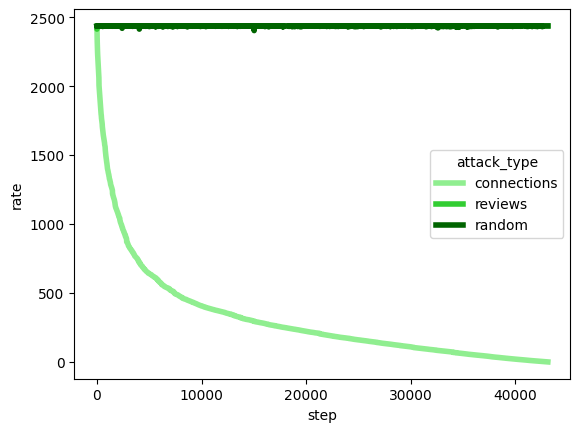

In [37]:
green_palette = ["#90EE90", "#32CD32", "#006400"]
sns.lineplot(
    data=_df.sort("step"), 
    x='step', 
    y='rate', 
    hue='attack_type', 
    palette=green_palette,
    linewidth=4  # Adjust this value to change thickness
)